In [3]:
import numpy as np
import matplotlib.pyplot as plt


from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "scripts"))

from kernel import motion_blur_psf

In [4]:
# Same PSF used to generate the blurred images

length = 21
angle_deg = 0

psf = motion_blur_psf(length=length, angle_deg=angle_deg)

print("PSF shape:", psf.shape)
print("PSF sum:", psf.sum())

PSF shape: (21, 21)
PSF sum: 0.9999999999999999


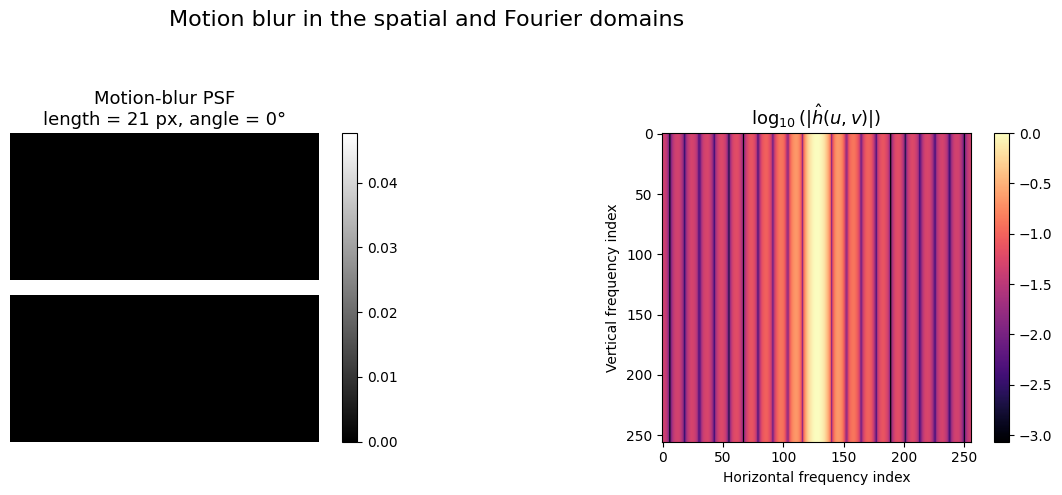

In [6]:
# 2D Fourier transform of the PSF

fft_shape = (256, 256)

H = np.fft.fft2(
    np.fft.ifftshift(psf),
    s=fft_shape
)

H_shifted = np.fft.fftshift(H)

H_magnitude = np.abs(H_shifted)

# Logarithmic scale avoids problems with log(0)
log_H_magnitude = np.log10(H_magnitude + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].imshow(psf, cmap="gray")
axes[0].set_title(
    f"Motion-blur PSF\nlength = {length} px, angle = {angle_deg}°",
    fontsize=13
)
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(log_H_magnitude, cmap="magma")
axes[1].set_title(
    r"$\log_{10}(|\hat{h}(u,v)|)$",
    fontsize=13
)
axes[1].set_xlabel("Horizontal frequency index")
axes[1].set_ylabel("Vertical frequency index")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle("Motion blur in the spatial and Fourier domains", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### Interpretation of the PSF Fourier response

The left panel shows the spatial representation of the selected motion-blur PSF. Since the angle is $0^\circ$, the kernel is a horizontal line: during the exposure, each pixel intensity is averaged along the horizontal direction over approximately $21$ pixels.

The right panel shows the logarithm of the magnitude of its two-dimensional Fourier transform, $\log_{10}(|\hat{h}(u,v)|)$. The response is independent of the vertical frequency index, producing vertical bands, because the PSF has no extension along the vertical direction. Therefore, the blur mainly affects horizontal spatial frequencies.

The bright central band corresponds to low frequencies, which are transmitted almost unchanged. Moving away from the centre, the Fourier magnitude oscillates and becomes very small at several vertical dark bands. These dark regions correspond to frequencies that are strongly attenuated or nearly cancelled by the motion blur.

This explains why direct deconvolution is unstable. In the Fourier domain, an inverse filter would require

$$
\hat{f}(u,v) = \frac{\hat{g}(u,v)}{\hat{h}(u,v)}.
$$

At frequencies where $|\hat{h}(u,v)|$ is close to zero, the division strongly amplifies the noise component. Consequently, even a small amount of Gaussian noise in the blurred observation can lead to large reconstruction errors, showing the ill-posed nature of the motion deblurring problem.

### SVD analysis of the blur operator

The forward model for one two-dimensional image channel can be written in vector form as

$$
\mathbf{g} = A_{\mathrm{gray}} \mathbf{f} + \boldsymbol{\epsilon},
$$

where $\mathbf{f}$ and $\mathbf{g}$ are the clean and blurred images reshaped into vectors, $\boldsymbol{\epsilon}$ is the noise vector, and $A_{\mathrm{gray}}$ is the matrix representing the two-dimensional convolution with the motion-blur PSF.

For an image of size $N_y \times N_x$, the vectorized image contains

$$
N = N_y N_x
$$

pixels, and therefore

$$
A_{\mathrm{gray}} \in \mathbb{R}^{N \times N}.
$$

For the original images, which have several hundred pixels in each direction, the corresponding blur matrix would be extremely large. For example, for a $512 \times 512$ image,

$$
A_{\mathrm{gray}} \in \mathbb{R}^{262144 \times 262144}.
$$

Constructing this matrix explicitly and computing its full singular value decomposition would be computationally impractical.

For this reason, the SVD analysis is performed on a smaller spatial grid, for example $32 \times 32$. The resulting matrix is not numerically identical to the operator acting on the full-resolution image, because the discretization is coarser and samples the Fourier response less densely. However, it represents the same physical blur mechanism and preserves the important features relevant to ill-posedness: strongly attenuated frequencies, very small singular values, and poor stability of the inverse problem.

Although the input data are RGB images, the same blur operator is applied independently to the red, green, and blue channels. No colour mixing is introduced by the forward model. If the three channels are stacked into a single vector, the full RGB operator has the block-diagonal form

$$
A_{\mathrm{RGB}} =
\begin{pmatrix}
A_{\mathrm{gray}} & 0 & 0 \\
0 & A_{\mathrm{gray}} & 0 \\
0 & 0 & A_{\mathrm{gray}}
\end{pmatrix}.
$$

Equivalently,

$$
A_{\mathrm{RGB}} = I_3 \otimes A_{\mathrm{gray}},
$$

where $I_3$ is the $3 \times 3$ identity matrix and $\otimes$ denotes the Kronecker product.

Therefore, the singular values of $A_{\mathrm{RGB}}$ are exactly the singular values of $A_{\mathrm{gray}}$, each repeated three times. It is consequently sufficient to analyse the SVD of the single-channel operator $A_{\mathrm{gray}}$.

### Construction of the discrete blur matrix

To analyse the stability of the inverse problem, the two-dimensional blur operator was written explicitly as a matrix $A_{\mathrm{gray}}$ on a reduced grid of size $32 \times 32$.

For a single-channel image, the image is first reshaped into a vector:

$$
\mathbf f \in \mathbb R^{N},
\qquad
N = 32 \times 32 = 1024.
$$

The blurred image is represented by

$$
\mathbf g = A_{\mathrm{gray}} \mathbf f.
$$

The matrix was built column by column. For each pixel index $j$, we created a basis image $\mathbf e_j$ containing one at pixel $j$ and zero elsewhere. We then applied the same two-dimensional motion-blur function used in the forward model, including reflective padding, to this basis image.

The resulting blurred basis image forms the $j$-th column of $A_{\mathrm{gray}}$:

$$
A_{\mathrm{gray}} \mathbf e_j
=
\text{blurred basis image}_j.
$$

Therefore, each column describes how the intensity initially located at one input pixel is spread over the output image by the motion PSF. Repeating this procedure for all $1024$ basis images gives

$$
A_{\mathrm{gray}} \in \mathbb R^{1024 \times 1024}.
$$

In [8]:


project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "scripts"))

from operators import apply_motion_blur

def build_blur_matrix(image_shape, psf):
    """
    Build the explicit matrix representation of the 2D blur operator.

    The matrix satisfies:
        g_vector = A_gray @ f_vector

    Parameters
    ----------
    image_shape : tuple[int, int]
        Shape of the small single-channel image, e.g. (32, 32).
    psf : numpy.ndarray
        Motion-blur PSF.

    Returns
    -------
    A_gray : numpy.ndarray
        Explicit blur matrix of shape (N, N), where N = height * width.
    """
    height, width = image_shape
    n_pixels = height * width

    A_gray = np.zeros((n_pixels, n_pixels), dtype=float)

    for j in range(n_pixels):
        basis_image = np.zeros(image_shape, dtype=float)
        basis_image.flat[j] = 1.0

        blurred_basis = apply_motion_blur(basis_image, psf)

        A_gray[:, j] = blurred_basis.ravel()

    return A_gray

In [9]:
small_shape = (32, 32)

psf = motion_blur_psf(length=21, angle_deg=0)

A_gray = build_blur_matrix(small_shape, psf)

print("A_gray shape:", A_gray.shape)

A_gray shape: (1024, 1024)


The matrix was then checked by comparing the result of direct convolution with the result obtained from matrix multiplication:

$$
\operatorname{vec}(g)
=
A_{\mathrm{gray}} \operatorname{vec}(f).
$$

The two results agree up to numerical precision, confirming that the matrix correctly represents the discrete blur operator on the reduced grid.

In [10]:
#TEST: matrix vs convolution

rng = np.random.default_rng(seed=123)

test_image = rng.random(small_shape)

blur_from_function = apply_motion_blur(test_image, psf)
blur_from_matrix = (A_gray @ test_image.ravel()).reshape(small_shape)

difference = np.max(np.abs(blur_from_function - blur_from_matrix))

print("Maximum absolute difference:", difference)

Maximum absolute difference: 4.440892098500626e-16


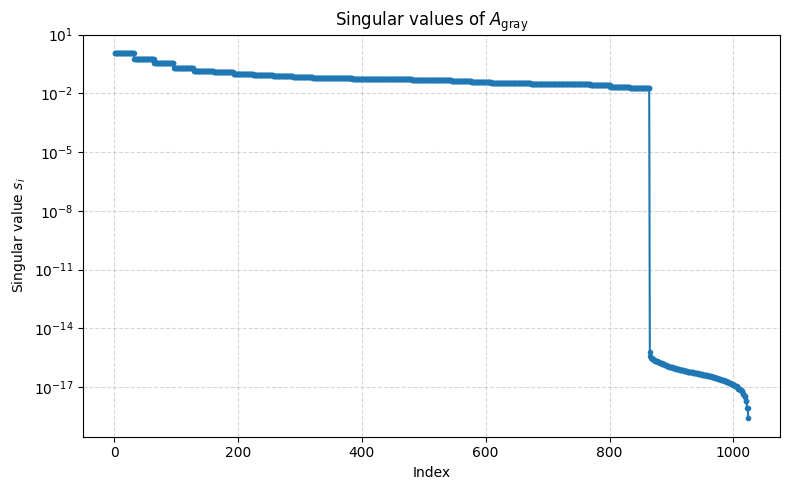

In [19]:
# Compute the singular values of A_gray

singular_values = np.linalg.svd(A_gray, compute_uv=False)

indices = np.arange(1, len(singular_values) + 1)

plt.figure(figsize=(8, 5))

plt.semilogy(
    indices,
    singular_values,
    marker=".",
    linestyle="solid"
)

plt.xlabel("Index")
plt.ylabel(r"Singular value $s_i$")
plt.title(r"Singular values of $A_{\mathrm{gray}}$")
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [21]:
# Frobenius-norm condition number using numerically nonzero singular values

sigma_valid = singular_values

condition_number_fro = (
    np.sqrt(np.sum(sigma_valid**2))
    *
    np.sqrt(np.sum(1.0 / sigma_valid**2))
)

print(f"Frobenius condition number: {condition_number_fro:.6e}")

Frobenius condition number: 3.614948e+19


### Interpretation of the singular-value spectrum and Frobenius condition number

The singular values of $A_{\mathrm{gray}}$ confirm the behaviour already observed in the Fourier-domain analysis of the PSF.

The Fourier magnitude plot showed several dark vertical bands where $|\hat{h}(u,v)|$ becomes very small. These regions correspond to horizontal spatial-frequency components that are strongly attenuated by the motion blur. Although the present operator uses reflective padding, the same attenuation mechanism appears in the singular-value spectrum.

The first part of the spectrum decreases gradually from the largest singular values to values of order $10^{-2}$. These components are attenuated by the blur but still remain partially observable. Around index $850$, however, the spectrum exhibits a sharp drop of many orders of magnitude. The remaining singular values are close to machine precision, approximately between $10^{-15}$ and $10^{-18}$.

This means that the blur operator has directions that are almost completely removed from the observed data. A direct inversion would require division by these extremely small singular values, strongly amplifying the Gaussian noise contained in the blurred image.

To quantify this instability, we computed the condition number using the Frobenius norm:

$$
\kappa_F(A)
=
\|A\|_F \|A^{-1}\|_F.
$$

Using the singular values, it can be written as

$$
\kappa_F(A)
=
\sqrt{
\left(\sum_i \sigma_i^2\right)
\left(\sum_i \frac{1}{\sigma_i^2}\right)
}.
$$

For the present blur operator, we obtained

$$
\kappa_F(A_{\mathrm{gray}})
=
3.61 \times 10^{19}.
$$

This extremely large value confirms that the deblurring problem is severely ill-conditioned: small perturbations in the blurred image can produce very large errors in a direct reconstruction. Therefore, regularization methods are required to obtain stable restored images.